# Inverse Physics-Informed Neural Network (IPINN) for Tumor Growth

This notebook implements an IPINN to learn the parameters of a tumor growth model from observational data.

## Model Equation
The tumor growth follows a generalized logistic equation:
$$\frac{dp}{dt} = k \cdot p \cdot \left(1 - \left(\frac{p}{c}\right)^\theta\right)$$

Where:
- $p(t)$ is the tumor volume at time $t$
- $k$ is the growth rate parameter (to be learned)
- $c$ is the carrying capacity (to be learned)
- $\theta$ is the exponent parameter (to be learned)

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

![image](images\data.png)

In [2]:
# =========================================================
# 1. Tumor Growth Data
# =========================================================
data = [
    (3.46, 0.0158), (4.58, 0.0264), (5.67, 0.0326), (6.64, 0.0445), (7.63, 0.0646),
    (8.41, 0.0933), (9.32, 0.1454), (10.27, 0.2183), (11.19, 0.2842),
    (12.39, 0.4977), (13.42, 0.6033), (15.19, 0.8441), (16.24, 1.2163),
    (17.23, 1.4470), (18.18, 2.3298), (19.29, 2.5342), (21.23, 3.0064),
    (21.99, 3.4044), (24.33, 3.2046), (25.58, 4.5241), (26.43, 4.3459),
    (27.44, 5.1374), (28.43, 5.5376), (30.49, 4.8946), (31.34, 5.0660),
    (32.34, 6.1494), (33.00, 6.8548), (35.20, 5.9668), (36.34, 6.6395),
    (37.29, 6.6395), (38.50, 6.8971), (39.67, 7.2966), (41.37, 7.2268),
    (42.58, 6.8815), (45.39, 8.0993), (46.38, 7.2112), (48.29, 7.0694),
    (49.24, 7.4971), (50.19, 6.9974), (51.14, 6.7219), (52.10, 7.0523),
    (54.00, 7.1095), (56.33, 7.0694), (57.33, 8.0562), (59.38, 7.2268)
]

In [3]:
t_obs = np.array([d[0] for d in data], dtype=np.float32).reshape(-1, 1)
p_obs = np.array([d[1] for d in data], dtype=np.float32).reshape(-1, 1)

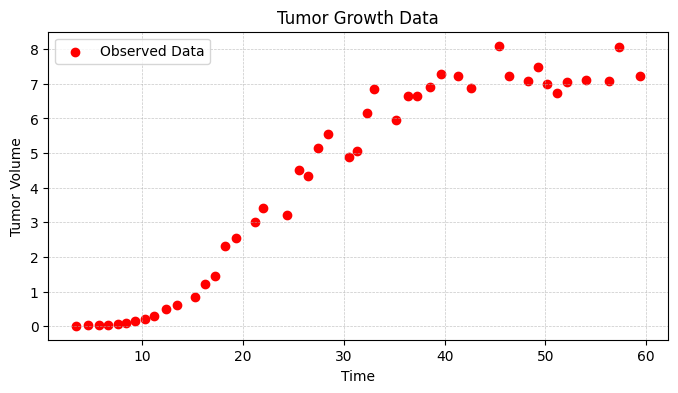

In [4]:
# Plot the data points
plt.figure(figsize=(8, 4))
plt.scatter(t_obs, p_obs, color='red', label='Observed Data')
plt.xlabel('Time')
plt.ylabel('Tumor Volume')
plt.title('Tumor Growth Data')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend()
plt.show()

![image](images\PINN.png)

In [5]:
# =========================================================
# 2. PINN Model
# =========================================================
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(1, activation='softplus')  # p(t) > 0
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# =========================================================
# 3. Trainable Montroll Parameters
# =========================================================
k     = tf.Variable(0.3, dtype=tf.float32, trainable=True)
C     = tf.Variable(9.0, dtype=tf.float32, trainable=True)
theta = tf.Variable(0.5, dtype=tf.float32, trainable=True)

The physics-based loss term is given by


$$L_{\text{physics}} = \frac{1}{N_R} \sum_{j=1}^{N_R} R^2(t_j)
\tag{5} $$

where,
 - \($N_R$\): the number of collocation points
 - \($R(t_j$)\): the residual of the model at point \($t_j$\)

In [7]:
# =========================================================
# 4. Physics Loss (Montroll ODE)
# =========================================================
def physics_loss(t):
    with tf.GradientTape() as tape:
        tape.watch(t)
        p = model(t)
    dp_dt = tape.gradient(p, t)

    rhs = k * p * (1.0 - (p / C) ** theta)
    residual = dp_dt - rhs

    return tf.reduce_mean(tf.square(residual))

For a given set of data points \(\{$x_i, y_i$\}$_{i=1}^{N}$\), where \($x_i$\) denotes the input variables and \($y_i$\) corresponds to the observed target values, the data-driven loss is defined as

$$L_{\text{data}} = \frac{1}{N} \sum_{i=1}^{N} \left( p(t_i) - y_i \right)^2
\tag{4}$$

Here, 
 - \($p(t_i)$\): the output of the neural network
 - \($t_i$\): the input of the neural network
 - \($N$\): the total number of data points

In [8]:
# =========================================================
# 5. Data Loss (IC included implicitly)
# =========================================================
def data_loss():
    p_pred = model(t_obs)
    return tf.reduce_mean(tf.square(p_pred - p_obs))

The Physics-Informed Neural Network (PINN) was trained by minimizing a physics-informed loss function that combines a data-driven error term with a physics-based constraint term. The overall loss function is defined as

$$L_{\text{PINN}} = L_{\text{data}} + \lambda L_{\text{physics}}$$

where \($L_{\text{data}}$\) represents the data fidelity term, \($L_{\text{physics}}$\) enforces adherence to the underlying growth model equations, and \($\lambda$\) is a regularization parameter \[5\].

In [9]:
# =========================================================
# 6. Training Setup
# =========================================================
t_phys = tf.linspace(t_obs.min(), t_obs.max(), 500)[:, None]

lambda_phys = 100.0
epochs = 17000
optimizer = tf.keras.optimizers.Adam(1e-3)

train_vars = model.trainable_variables + [k, C, theta]

loss_history = []
param_history = []

@tf.function
def train_step():
    with tf.GradientTape() as tape:
        Ld = data_loss()
        Lp = physics_loss(t_phys)
        L  = Ld + lambda_phys * Lp   
    grads = tape.gradient(L, train_vars)
    optimizer.apply_gradients(zip(grads, train_vars))
    return L, Ld, Lp


In [10]:
# =========================================================
# 7. Training Loop
# =========================================================
for epoch in range(epochs):
    L, Ld, Lp = train_step()

    loss_history.append(L.numpy())
    param_history.append([
        k.numpy(),
        C.numpy(),
        theta.numpy()
    ])

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | "
              f"Loss={L.numpy():.3e} | "
              f"k={k.numpy():.3f}, C={C.numpy():.3f}, θ={theta.numpy():.3f}")

print("\nFinal learned parameters:")
print("k =", k.numpy(), "C =", C.numpy(), "theta =", theta.numpy())

Epoch     0 | Loss=2.415e+01 | k=0.299, C=8.999, θ=0.499
Epoch  1000 | Loss=3.068e-01 | k=0.233, C=8.704, θ=0.404
Epoch  2000 | Loss=2.244e-01 | k=0.273, C=8.261, θ=0.399
Epoch  3000 | Loss=1.442e-01 | k=0.324, C=7.710, θ=0.417
Epoch  4000 | Loss=1.264e-01 | k=0.354, C=7.420, θ=0.427
Epoch  5000 | Loss=1.254e-01 | k=0.367, C=7.379, θ=0.417
Epoch  6000 | Loss=1.250e-01 | k=0.382, C=7.381, θ=0.398
Epoch  7000 | Loss=1.246e-01 | k=0.403, C=7.386, θ=0.372
Epoch  8000 | Loss=1.243e-01 | k=0.434, C=7.393, θ=0.341
Epoch  9000 | Loss=1.238e-01 | k=0.474, C=7.400, θ=0.308
Epoch 10000 | Loss=1.235e-01 | k=0.521, C=7.407, θ=0.277
Epoch 11000 | Loss=1.233e-01 | k=0.570, C=7.413, θ=0.249
Epoch 12000 | Loss=1.232e-01 | k=0.620, C=7.418, θ=0.227
Epoch 13000 | Loss=1.230e-01 | k=0.667, C=7.422, θ=0.209
Epoch 14000 | Loss=1.229e-01 | k=0.710, C=7.425, θ=0.195
Epoch 15000 | Loss=1.228e-01 | k=0.747, C=7.428, θ=0.185
Epoch 16000 | Loss=1.227e-01 | k=0.780, C=7.430, θ=0.176

Final learned parameters:
k = 

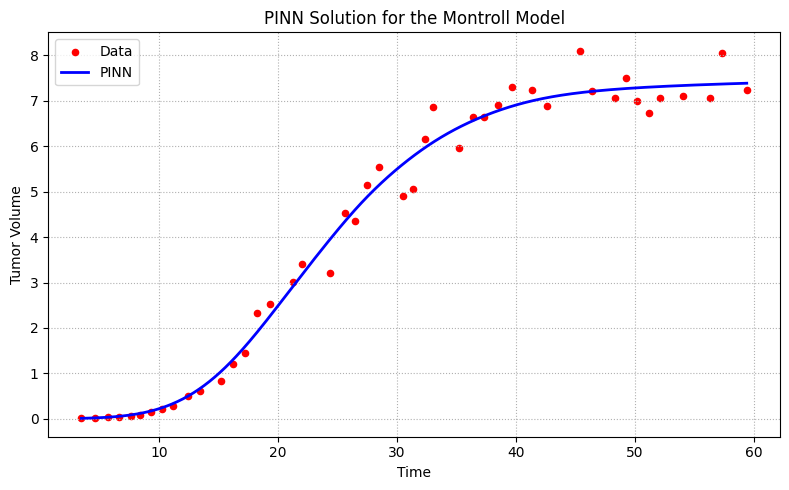

In [11]:
# =========================================================
# 8. Plot PINN Solution vs Data
# =========================================================
t_plot = np.linspace(t_obs.min(), t_obs.max(), 500).astype(np.float32).reshape(-1, 1)
p_plot = model(t_plot)

plt.figure(figsize=(8, 5))
plt.scatter(t_obs, p_obs, c='red', s=20, label='Data')
plt.plot(t_plot, p_plot, 'b-', linewidth=2, label='PINN')
plt.xlabel('Time')
plt.ylabel('Tumor Volume')
plt.title('PINN Solution for the Montroll Model')
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

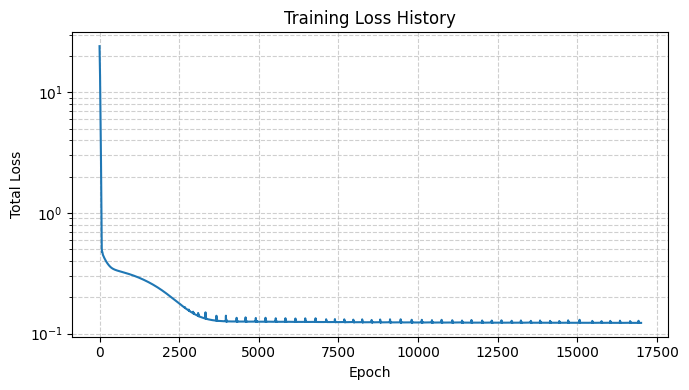

In [12]:
# =========================================================
# 9. Plot Training Loss History
# =========================================================
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Training Loss History')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

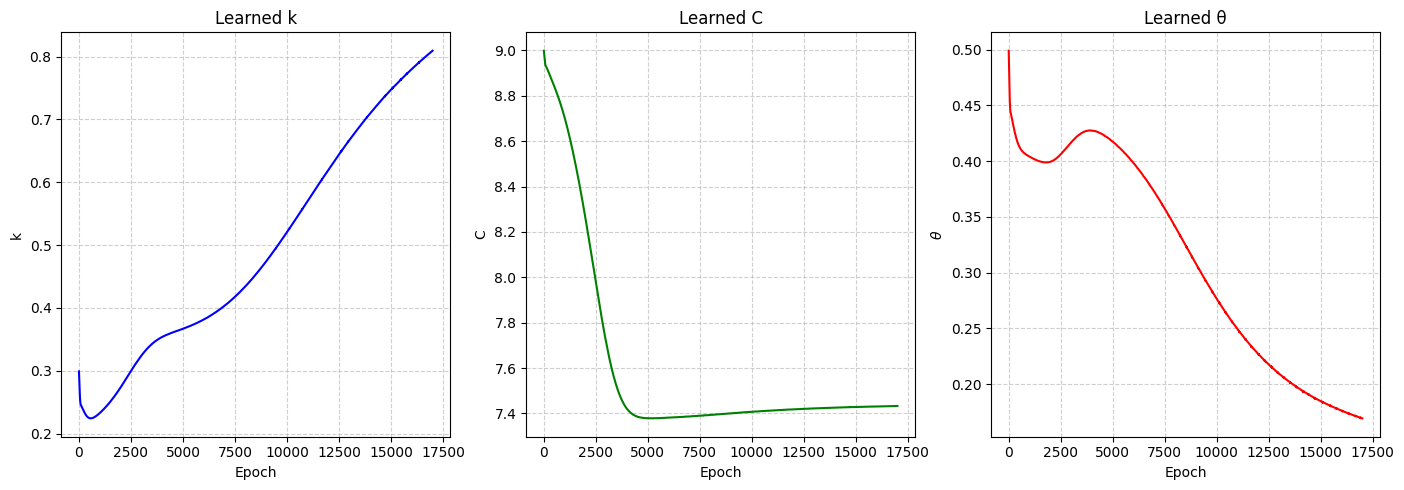

In [13]:
# =========================================================
# 10. Plot Learned Parameter History
# =========================================================
param_history = np.array(param_history)

epochs_axis = np.arange(len(param_history))

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs_axis, param_history[:, 0], 'b')
plt.xlabel('Epoch')
plt.ylabel('k')
plt.title('Learned k')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 2)
plt.plot(epochs_axis, param_history[:, 1], 'g')
plt.xlabel('Epoch')
plt.ylabel('C')
plt.title('Learned C')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 3)
plt.plot(epochs_axis, param_history[:, 2], 'r')
plt.xlabel('Epoch')
plt.ylabel(r'$\theta$')
plt.title('Learned θ')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()